### 課題1

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
s = np.random.rand(100, 1) * 2 * np.pi
Z = np.hstack([2*np.cos(s), 3*np.sin(s)])
P = np.random.randn(2,5)
X = Z @ P + np.random.randn(100, 5)
X

array([[-5.69824699e-01,  3.49860903e-01,  1.47314679e+00,
         4.71903017e+00,  2.12002644e+00],
       [-3.20686931e+00, -7.19752325e-03,  6.07588507e-01,
        -5.18089370e+00, -4.14662859e+00],
       [-7.16019387e-01, -1.18067563e+00,  1.30628548e+00,
        -2.26831969e+00,  1.08947813e+00],
       [-2.63309473e+00, -3.01554673e+00, -1.25135642e+00,
        -6.35665787e+00, -6.74396482e+00],
       [-4.36180758e-01,  3.40207103e-01, -5.27537644e+00,
        -5.30343898e+00, -4.65119530e+00],
       [-6.80004076e-01,  4.61512410e-01,  2.57470506e+00,
        -1.23621415e+00, -1.00319624e-01],
       [-1.64749174e-01,  8.67630628e-01, -2.79792814e+00,
        -7.48617466e+00, -3.98924864e+00],
       [-1.25966683e+00,  7.68225308e-01, -2.61323461e+00,
        -3.38270104e+00, -4.24229981e+00],
       [ 1.63146181e+00,  1.26190868e-01, -7.78725209e-02,
         4.87470293e+00,  2.86207360e+00],
       [-1.87946257e+00, -8.90307367e-01, -6.75870820e-01,
        -5.16425829e+00

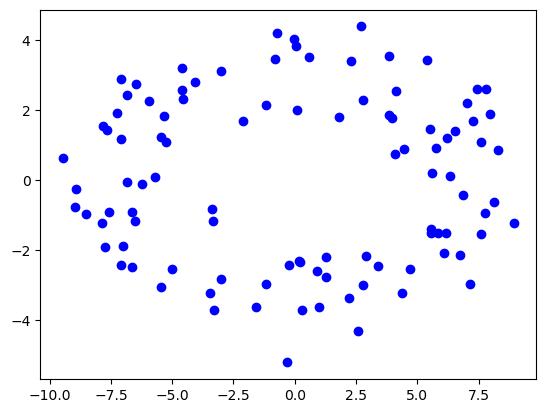

In [9]:
# データを中心化
X_centered = X - X.mean(axis=0)

# 共分散行列を計算
M = (X_centered.T @ X_centered) / X_centered.shape[0]

# 固有値と固有ベクトルを計算
eigvals, eigvecs = np.linalg.eigh(M)

# 固有値の大きい順に並べた
idx = np.argsort(eigvals)[::-1]
# 上位2固有ベクトルを選択
W = eigvecs[:, idx[:2]]
# データを2次元に射影
X_2d = X_centered @ W
# 2D散布図をプロット
plt.scatter(X_2d[:, 0], X_2d[:, 1],color = 'blue')


### 課題2

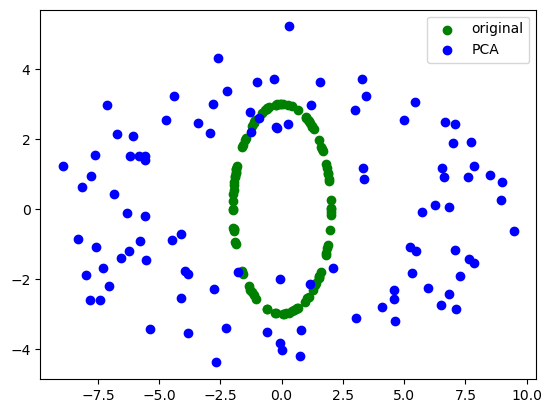

In [10]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

Xpca = PCA(n_components=2).fit_transform(X)
plt.scatter(Z[:, 0], Z[:, 1], label='original',color = 'green')
plt.scatter(Xpca[:, 0], Xpca[:, 1], label='PCA',color = 'blue')
plt.legend()

### 課題3

寄与率: [0.92461872 0.05306648]
累積寄与率: 0.977685206318798


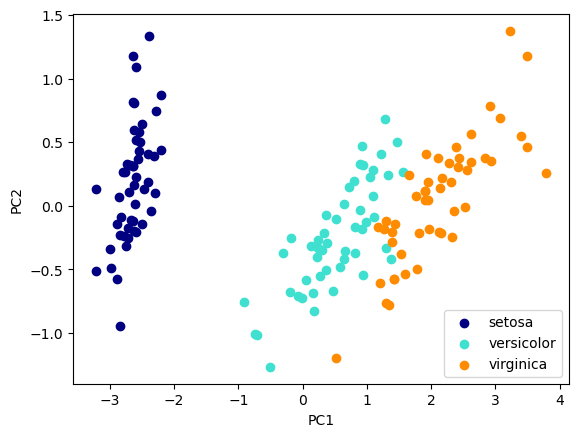

In [15]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
target_names = iris.target_names

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)

explained = pca.explained_variance_ratio_
print("寄与率:", explained)
print("累積寄与率:", explained.sum())

colors = ['navy', 'turquoise', 'darkorange']
for i, color in enumerate(colors):
    plt.scatter(X_pca[y_iris == i, 0], X_pca[y_iris == i, 1], color=color, label=target_names[i])

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()

考察を書く